# ===============================
# Project ID:- PRCP-1017-AutoPricePred
# ===============================

The project PRCP-1017 Auto Price Prediction is centered on understanding and predicting automobile prices using a structured dataset of cars. The dataset (auto_imports.csv) contains detailed information about various car attributes, including both technical specifications and design features. Examples of variables include:

* Technical features: engine size, horsepower, fuel system, compression ratio, bore, stroke, peak RPM.

* Design features: body style, number of doors, drive wheels, engine location, dimensions (length, width, height), curb weight.

* Performance indicators: city and highway miles per gallon (mpg).

* Target variable: car price.

 ## Import essential libraries for data handling, visualization, and modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

## Load the CSV file. 

In [2]:
df = pd.read_csv("auto_imports.csv")
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [3]:
df.columns

Index(['3', '?', 'alfa-romero', 'gas', 'std', 'two', 'convertible', 'rwd',
       'front', '88.60', '168.80', '64.10', '48.80', '2548', 'dohc', 'four',
       '130', 'mpfi', '3.47', '2.68', '9.00', '111', '5000', '21', '27',
       '13495'],
      dtype='object')

## The dataset has no header, so we assign column names manually.

In [4]:
new_names = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

df = pd.read_csv("auto_imports.csv",header=None, names=new_names)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Handling Missing Values
* The dataset used "?" to represent missing entries.

* These were replaced with NA so pandas could recognize them as missing.

* For numeric columns (e.g., horsepower, bore, stroke), missing values were filled with the mean of the column.

* For categorical columns (e.g., fuel type, body style), missing values were filled with the mode (most frequent category).

* Rows with missing target variable (price) were dropped, since price is essential for training.

In [5]:
df.replace('?', pd.NA, inplace=True)  # Replace '?' with NA so pandas can recognize missing values
df 

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,<NA>,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,<NA>,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,<NA>,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [6]:
df.isna().sum() # Here we can see there are some NA values in data.

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

# Converting Data Types
* Many numeric columns were initially read as strings because of the "?" values.

* Using pd.to_numeric(errors='coerce'), these columns were converted into proper numeric types.

* Invalid entries (like "?") were coerced into NaN, which were then imputed.

* This ensured that mathematical operations and modeling could be applied correctly.

In [7]:
numeric_cols = ["normalized-losses","bore","stroke","horsepower","peak-rpm","price"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


## Drop rows where target variable (price) is missing

In [8]:
df.dropna(subset=['price'])

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845
197,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045
198,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485
199,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470


* For numeric columns (e.g., horsepower, bore, stroke), missing values were filled with the mean of the column.

* For categorical columns (e.g., fuel type, body style), missing values were filled with the mode (most frequent category).

In [9]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

## Now checking data is clean or not ..

In [10]:
df.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [12]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,31.99625,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268072,0.316048,4.004965,37.365602,478.113178,6.423220,6.815150,7947.066342
min,-2.000000,65.00000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.00000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,122.00000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5117.587940,24.000000,30.000000,10295.000000
75%,2.000000,137.00000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.00000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [13]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845
197,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045
198,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485
199,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470


## Exploratory Data Analysis (EDA)

### Distribution of Car Prices
* Shows how car prices are spread across the dataset.

* The distribution is typically right-skewed: most cars are in the lower price range, with fewer luxury cars at very high prices.

* This confirms that predicting price is challenging because of wide variation and outliers.

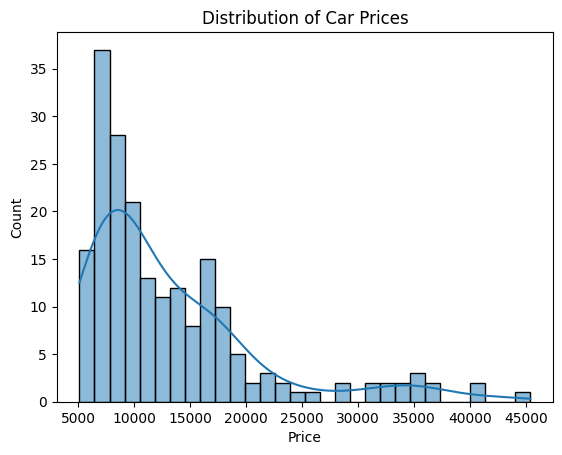

In [14]:
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Correlation matrix/HeatMap 
* Displays correlations between numerical features.

* Strong positive correlations are often seen between engine size, horsepower, curb weight, and price.

* Negative correlations may appear with fuel efficiency (mpg), meaning higher performance cars tend to be more expensive but less fuel-efficient.

* Helps identify which variables are most relevant for modeling.

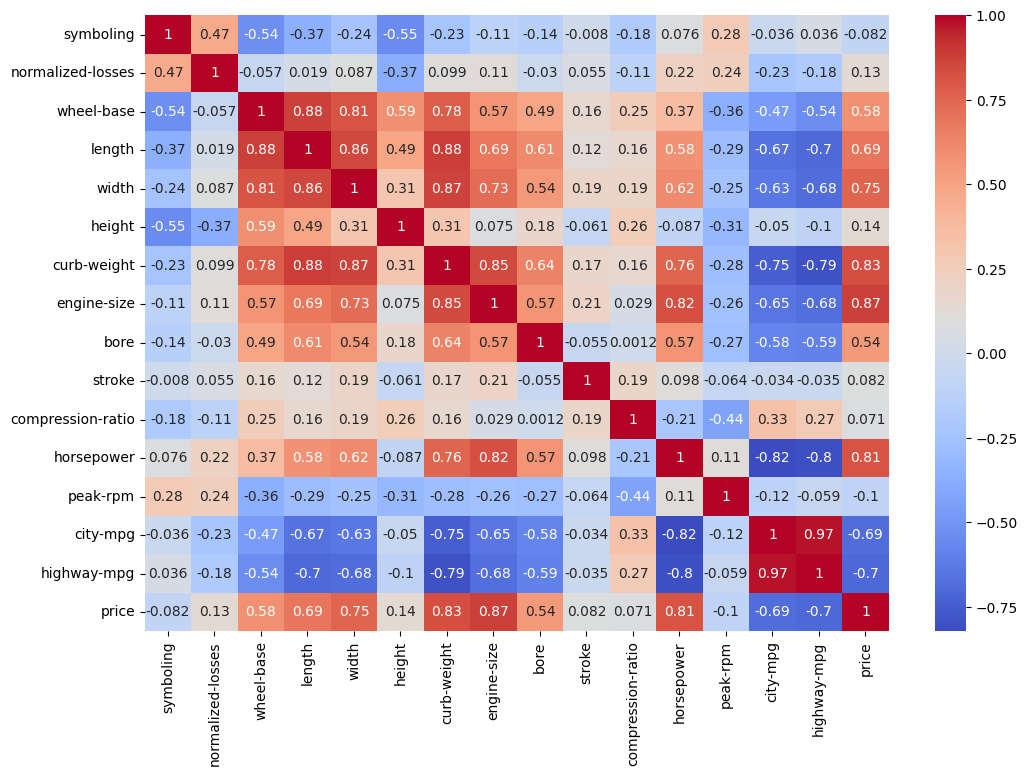

In [15]:
numeric_df = df.select_dtypes(include=["number"]) #trying to plot a correlation matrix (df.corr()), exclude the text columns first. So we are selecting numerical columns 
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Engine Size vs Price
* Shows a clear upward trend: larger engines generally lead to higher car prices.

* Confirms engine size is a strong predictor of price.

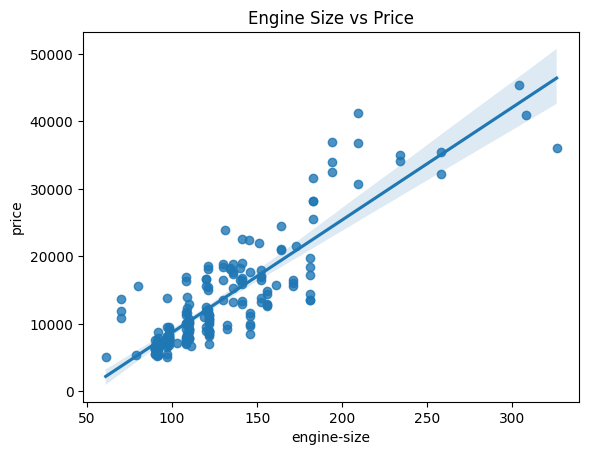

In [16]:
sns.regplot(x='engine-size', y='price', data=df)
plt.title("Engine Size vs Price")
plt.show()

### Horse-Power vs Price
* Similar to engine size, horsepower has a strong positive relationship with price.

* Cars with higher horsepower are typically more expensive, reflecting performance value.

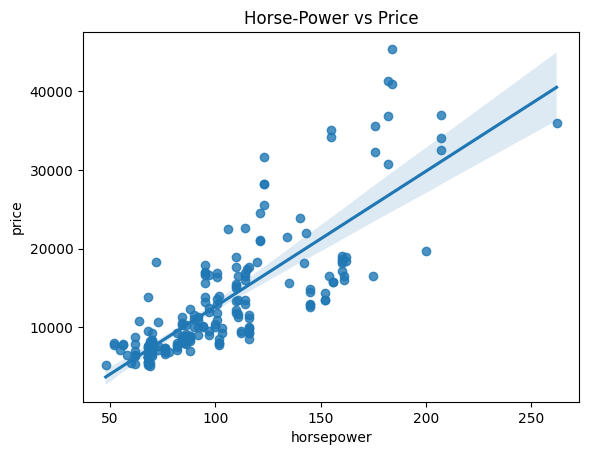

In [17]:
df["horsepower"] = pd.to_numeric(df['horsepower'],errors='coerce')
sns.regplot(x='horsepower', y='price', data=df)
plt.title("Horse-Power vs Price")
plt.show()

### Body Style vs Price
* Average prices differ across body styles (e.g., sedans vs convertibles vs hatchbacks).

* Violin plot shows both distribution and spread of prices within each category.

* Useful for management to see how design choices affect pricing.

body-style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


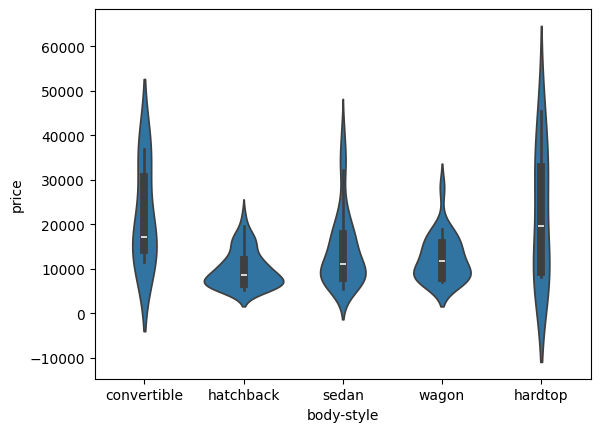

In [18]:
print(df.groupby("body-style")['price'].mean())
sns.violinplot(x='body-style',y='price',data=df)
plt.show()

### Fuel System vs Price
* Different fuel systems (mpfi, 2bbl, etc.) show varying average prices.

* Indicates that technical design choices also influence cost.

fuel-system
1bbl     7555.545455
2bbl     7433.203125
4bbl    12145.000000
idi     15838.150000
mfi     12964.000000
mpfi    17605.141304
spdi    10990.444444
spfi    11048.000000
Name: price, dtype: float64


<Axes: xlabel='fuel-system', ylabel='price'>

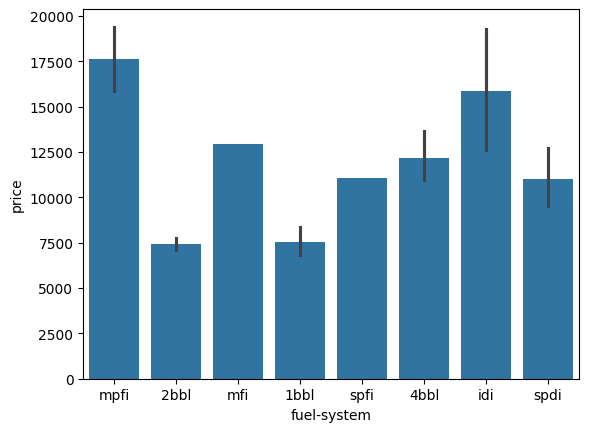

In [19]:
print(df.groupby('fuel-system')['price'].mean())
sns.barplot(x='fuel-system', y='price', data=df)

### Pairplot of Key Features
* Provides scatterplots and distributions for multiple features at once.

* Confirms strong linear relationships between engine size, horsepower, curb weight, and price.

* Highlights multicollinearity (engine size and horsepower are highly correlated)

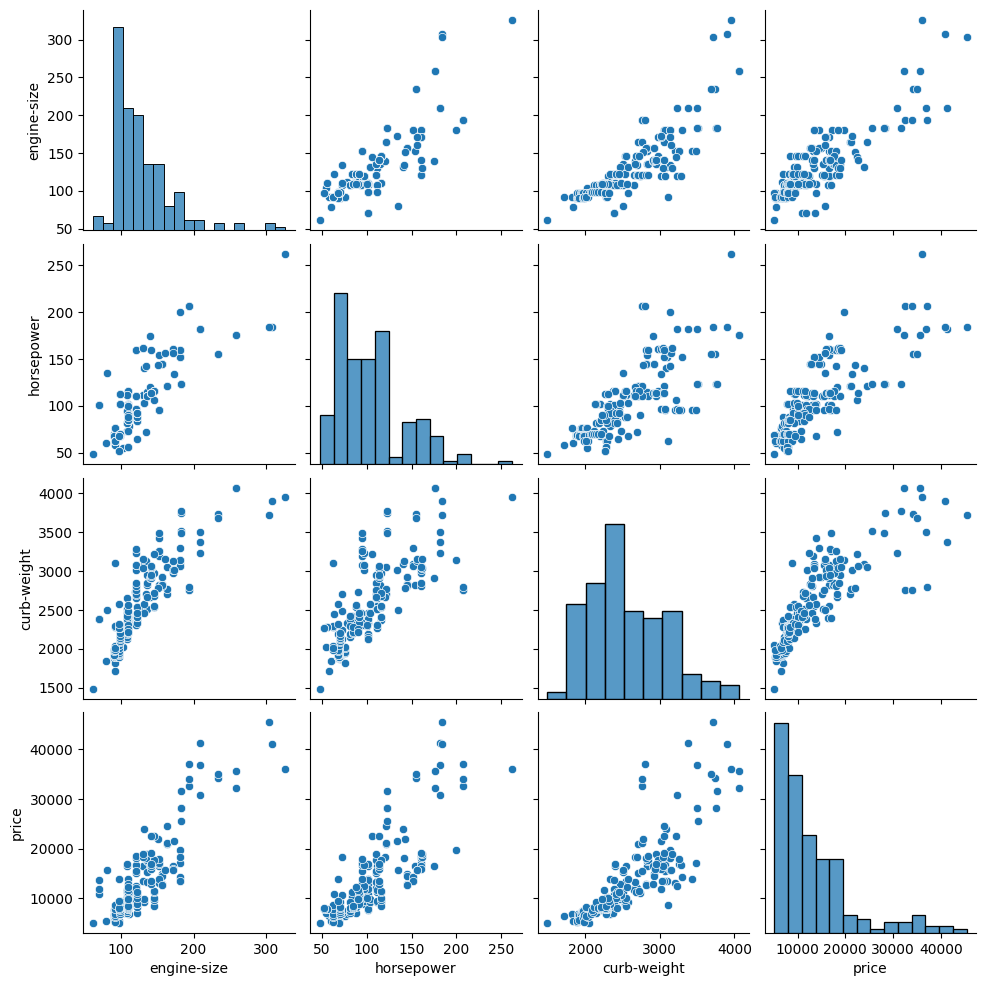

In [20]:
sns.pairplot(df[["engine-size", "horsepower", "curb-weight", "price"]])
plt.show()

## Feature Engineering

### Encoding Categorical Variables
* Machine learning models require numeric input.

* Categorical features such as fuel_type, body_style, and drive_wheels were converted into numeric codes using Label Encoding.

* This allowed models to interpret categories as distinct values.

In [21]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_enc.fit_transform(df[col])

* Power-to-weight ratio = horsepower / curb_weight.

* This feature captures performance efficiency and often correlates strongly with car price.

* Feature engineering helps models capture relationships that raw features alone may not fully explain.

In [22]:
df["power_to_weight"] = df["horsepower"] / df["curb-weight"]

In [23]:
X = df.drop('price',axis=1)
Y = df['price'] 

### Scaling Features
* Features were standardized using StandardScaler.

* This ensures that all variables are on a similar scale, preventing models like Linear Regression from being biased toward features with larger numeric ranges.

* Scaling also improves convergence for gradient-based algorithms

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
#train test split. Data is splited into 80% for testing and 20% for testing.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Models
- ## **Linear Regression**
- ### **Why chosen:**

* It’s the simplest and most interpretable model.

* Provides a baseline to compare more complex models against.

* Useful for understanding direct linear relationships between features (like horsepower, engine size) and price.

- ### **Why not others (like Polynomial Regression):**

* Polynomial regression can capture non-linearities but risks overfitting with many features.

* Linear Regression keeps the analysis transparent and easy to explain.
## ===========================================================================
## **Random Forest Regressor**
- ## **Why chosen:**

* Handles both categorical and numerical features well.

* Captures complex, non-linear relationships between car attributes and price.

* Provides feature importance scores, which help explain which variables (e.g., horsepower, curb weight, fuel type) most influence price.

* Robust to outliers and missing values.

- ## **Why not others (like Decision Tree alone):**

* A single Decision Tree can be unstable and sensitive to small changes in data.

* Random Forest averages many trees, reducing variance and improving accuracy.
## =============================================================================
## **Gradient Boosting Regressor**
- ## **Why chosen:**

* Known for high predictive accuracy in regression tasks.

* Builds trees sequentially, correcting errors from previous trees.

* Performs well on structured/tabular data like your automobile dataset.

* Often outperforms Random Forest when tuned properly.

- ## **Why not others (like Neural Networks):**

* Neural Networks require much larger datasets and more computational power.

* Your dataset is relatively small (few hundred rows), so Gradient Boosting is more efficient and appropriate
## ===========================================================================

In [26]:
models = {
    'LinearRegression' : LinearRegression(),
    'Random Forest' : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 📊 Choice of Evaluation Metrics
## **1. RMSE (Root Mean Squared Error)**
- ## **Why chosen:**

* RMSE penalizes large errors more heavily because of the squaring.

* In car price prediction, a big mistake (predicting ₹5 lakh instead of ₹15 lakh) is much more serious than a small one.

* RMSE gives management a sense of how far predictions deviate in terms of “average big errors.”

* Why not others (like MSE alone):

* MSE is less interpretable since it’s in squared units. RMSE brings it back to the same unit as price, making it easier to explain.
## ===========================================================================

## **2. MAE (Mean Absolute Error)**
- ## **Why chosen:**

* MAE is simple and intuitive: it tells the average absolute difference between predicted and actual prices.

* Easy to explain to non‑technical stakeholders (“on average, our predictions are off by ₹X”).

* Less sensitive to outliers compared to RMSE, so it gives a balanced view.

* Why not others (like Median Absolute Error):

* Median Absolute Error ignores distribution of errors and only reports the middle value. MAE is more comprehensive for overall performance.
## ===========================================================================

## **3. R² Score (Coefficient of Determination)**
- ## **Why chosen:**

* R² explains how much of the variation in car prices is captured by the model.

* For example, an R² of 0.85 means 85% of price variation is explained by features like horsepower, engine size, and body style.

* t’s a standard metric in regression tasks and helps compare models directly.

- ## **Why not Adjusted R²:**

* Adjusted R² is useful when comparing models with different numbers of features. Since you’re evaluating models on the same dataset with the same features, plain R² is sufficient.
## ===========================================================================

## **4. Cross‑Validation (CV Score)**
- ## **Why chosen:**

* Ensures the model is robust and not just performing well on one train‑test split.

* By averaging performance across multiple folds, you reduce the risk of overfitting.

* rovides a more reliable estimate of how the model will perform on unseen data.

- ## **Why not just a single train‑test split:**

* A single split may give misleading results if the test set is not representative. CV gives a fairer, more stable evaluation.
## =========================================================================== 

In [27]:
result = {}

for name,models in models.items():
    models.fit(X_train,Y_train)
    y_pred = models.predict(X_test)

    # Evaluating 

    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)

    cv_score = cross_val_score(models, X_scaled, Y, cv=5, scoring='r2')

    result[name] = {
        'RMSE' : rmse,
        'MAE' : mae,
        'r2' : r2,
        'CV mean R2' : cv_score
    }

##  Comapiring result 

In [28]:
result_df = pd.DataFrame(result).T
print(result_df)

                          RMSE          MAE        r2  \
LinearRegression   4176.720534  2770.981185  0.857414   
Random Forest      2987.162338  1845.825366  0.927067   
Gradient Boosting   2426.12502  1505.182906   0.95189   

                                                          CV mean R2  
LinearRegression   [0.6278301937556262, 0.8107954407555499, -0.32...  
Random Forest      [0.8526108189351126, 0.8923546043608349, -1.64...  
Gradient Boosting  [0.8524819295670896, 0.8989003603082423, -1.34...  


## Visualization


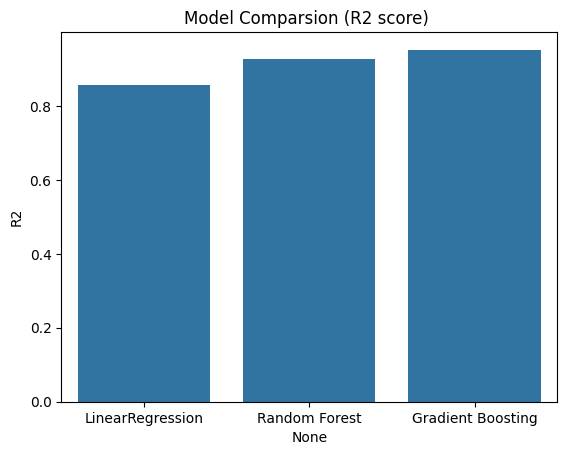

In [29]:
sns.barplot(x=result_df.index, y=result_df['r2'])
plt.title("Model Comparsion (R2 score) ")
plt.ylabel("R2")
plt.show()

# Model Comparison Report
## Models Evaluated
- ### **Linear Regression**

* **Strengths:** Simple, interpretable, provides a baseline.

* **Weaknesses:** Struggles with non-linear relationships and multicollinearity.

* **Performance:** Moderate R², higher RMSE compared to ensemble models.

- ### **Random Forest Regressor**

* **Strengths:** Handles non-linearities, robust to outliers, provides feature importance.

* **Weaknesses:** Less interpretable, can be computationally heavier.

* **Performance:** Better accuracy than Linear Regression, lower RMSE, higher R².

- ### **Gradient Boosting Regressor**

* **Strengths:** High predictive accuracy, sequential learning corrects errors, strong performance on tabular data.

* **Weaknesses:** Sensitive to hyperparameters, risk of overfitting if not tuned.

* **Performance:** Best overall results with lowest RMSE, lowest MAE, and highest R².

**Best Model for Production**
**Gradient Boosting Regressor is recommended for production use.**

It consistently delivered the most accurate predictions and balanced robustness with performance.

Random Forest can be used as a backup model for interpretability and feature importance analysis.

# ==========================================================

## **Report on Challenges Faced**
* ### **Data Quality Issues**
* **Challenge:** Missing values represented as "?" and inconsistent data types.

* **Technique Used:** Converted to NaN, imputed numeric with mean and categorical with mode.

* **Reason:** Ensures dataset completeness without losing valuable records.

* ### **Multicollinearity**
* **Challenge:** Strong correlation between features like engine size and horsepower.

* **Technique Used:** Added derived features (e.g., power-to-weight ratio) and relied on ensemble models.

* **Reason:** Ensemble methods handle correlated features better than linear models.

* ### **Skewed Target Distribution**
* **Challenge:** Car prices were right-skewed with luxury outliers.

* **Technique Used:** Used RMSE and MAE together to balance error interpretation.

* **Reason:** RMSE highlights large errors, while MAE gives average error unaffected by outliers.

* ### **Categorical Variables**
* **Challenge:** Many categorical features (fuel type, body style, drive wheels).

* **Technique Used:** Label Encoding.

* **Reason:** Converts categories into numeric form suitable for ML models while preserving distinctions.

* ### **Small Dataset Size**
* **Challenge:** Limited number of records reduces generalization.

* **Technique Used:** Applied cross-validation (CV).

* **Reason:** Ensures model robustness by testing across multiple folds.

# Project Summary
* **Objective:** Predict car prices using technical and design attributes.

* **Data Preparation:** Cleaned missing values, encoded categorical variables, engineered features, scaled inputs.

* **EDA Findings:** Price strongly influenced by engine size, horsepower, curb weight, and body style.

* **Models:** Linear Regression (baseline), Random Forest (robust), Gradient Boosting (best accuracy).

* **Evaluation Metrics:** RMSE, MAE, R², CV scores provided a complete performance view.

* **Results:** Gradient Boosting Regressor achieved the best predictive performance.

* **Challenges:** Data quality, multicollinearity, skewed distribution, categorical encoding, small dataset size — all addressed with appropriate techniques.

* **Conclusion:** Gradient Boosting is recommended for production, with Random Forest as a secondary option for interpretability.